# Слесарев Никита ФИТ-231, Лабораторная работа №4
### Задание 2
Скачайте файл с данными о публикациях на сайте Хабрахабр
(https://cloud.mail.ru/public/3ViL/q5xSM1TH2). Выполните следующие действия:
1. Изучите датасет, попробуйте понять какой столбец за что отвечает.


In [24]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('howpop_train.csv')

# Краткий обзор
print("Первые 5 строк:")
print(df.head())

print("\nИнформация о столбцах:")
print(df.info())

print("\nОписание числовых столбцов:")
print(df.describe())

Первые 5 строк:
                                url        domain  post_id  \
0  https://habrahabr.ru/post/18284/  habrahabr.ru    18284   
1  https://habrahabr.ru/post/18285/  habrahabr.ru    18285   
2  https://habrahabr.ru/post/18286/  habrahabr.ru    18286   
3  https://habrahabr.ru/post/18291/  habrahabr.ru    18291   
4  https://geektimes.ru/post/18294/  geektimes.ru    18294   

             published      author     flow polling content_len  \
0  2008-01-01 18:19:00      @Tapac  develop   False        4305   
1  2008-01-01 18:30:00  @DezmASter   design   False        7344   
2  2008-01-01 18:34:00  @DezmASter   design   False        8431   
3  2008-01-02 01:32:00    @Taoorus   design   False        5662   
4  2008-01-02 14:34:00    @dennydo      NaN   False        3706   

                                               title  comments  favs views  \
0     Новогодний подарок блоггерам — WordPress 2.3.2         0     0   236   
1  Сумасшедшие яйца, или сервис для отслеживания ...

C:\Users\Nikita\AppData\Local\Temp\ipykernel_7268\2428513171.py:4: DtypeWarning: Columns (6,7,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('howpop_train.csv')


2. Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с
помощью filter() и удалите drop-ом:
df.drop(
 filter(lambda c: c.endswith("_lognorm"), df.columns),
 axis=1, # axis = 1: столбцы
 inplace=True,
) # избавляет от необходимости сохранять датасет

In [25]:
# Удаляем столбцы с суффиксом _lognorm
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1,
    inplace=True
)

print("Оставшиеся столбцы:")
print(df.columns.tolist())

Оставшиеся столбцы:
['url', 'domain', 'post_id', 'published', 'author', 'flow', 'polling', 'content_len', 'title', 'comments', 'favs', 'views', 'votes_plus', 'votes_minus', 'Unnamed: 17', 'Unnamed: 18']


3. Столбец published (время публикации) содержит строки. Чтобы работать с этими
данными как с датой/временем публикации, приведите их к типу datetime:
df["published"] = pd.to_datetime(df.published, yearfirst=True)

In [26]:
import pandas as pd

# Преобразуем строку в дату-время
df["published"] = pd.to_datetime(df["published"], yearfirst=True)

print("Тип столбца 'published':", df["published"].dtype)
print(df["published"].head())

Тип столбца 'published': datetime64[ns]
0   2008-01-01 18:19:00
1   2008-01-01 18:30:00
2   2008-01-01 18:34:00
3   2008-01-02 01:32:00
4   2008-01-02 14:34:00
Name: published, dtype: datetime64[ns]


4. Создайте несколько столбцов на основе данных о времени публикации:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]
df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]


In [27]:
df["year"] = [d.year for d in df["published"]]
df["month"] = [d.month for d in df["published"]]
df["dayofweek"] = [d.isoweekday() for d in df["published"]]  # Пн = 1, Вс = 7
df["hour"] = [d.hour for d in df["published"]]

print(df[["published", "year", "month", "dayofweek", "hour"]].head())

            published  year  month  dayofweek  hour
0 2008-01-01 18:19:00  2008      1          2    18
1 2008-01-01 18:30:00  2008      1          2    18
2 2008-01-01 18:34:00  2008      1          2    18
3 2008-01-02 01:32:00  2008      1          3     1
4 2008-01-02 14:34:00  2008      1          3    14


5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого
года) было больше всего публикаций.


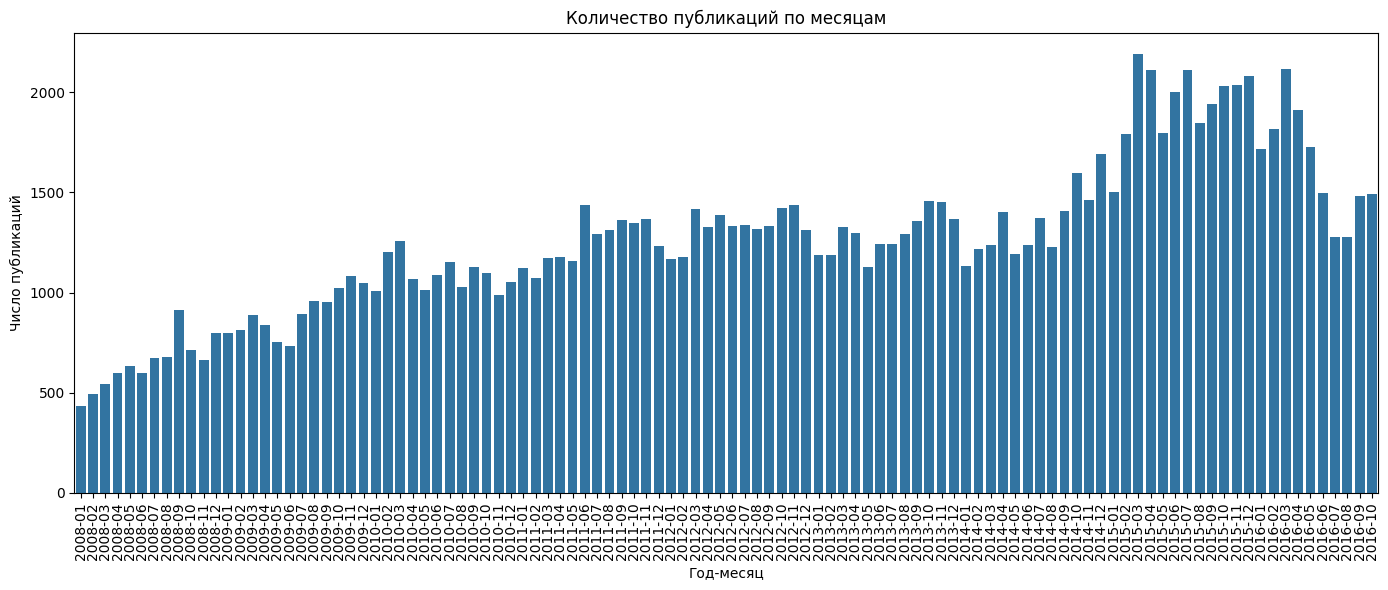

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Создаём столбец "год-месяц"
df["year_month"] = df["published"].dt.to_period("M")

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="year_month", order=sorted(df["year_month"].unique()))
plt.xticks(rotation=90)
plt.title("Количество публикаций по месяцам")
plt.xlabel("Год-месяц")
plt.ylabel("Число публикаций")
plt.tight_layout()
plt.show()

6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели,
используя параметр hue.

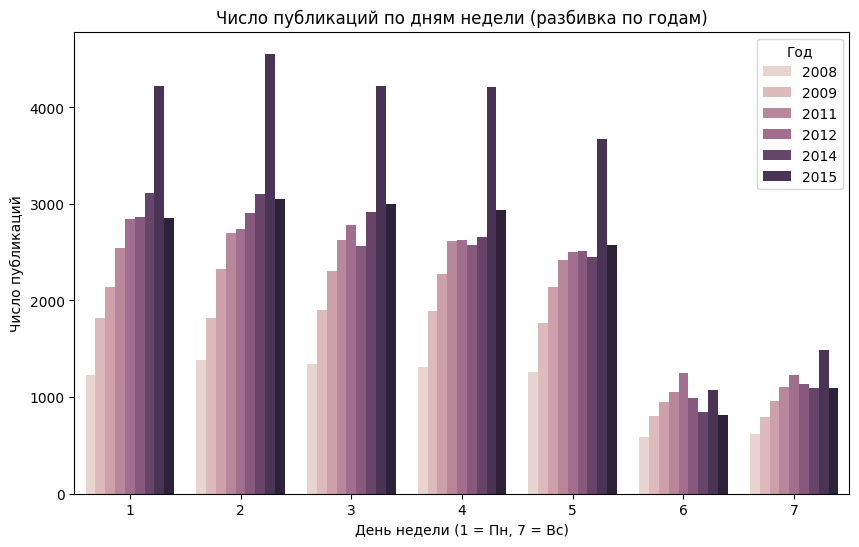

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="dayofweek", hue="year")
plt.title("Число публикаций по дням недели (разбивка по годам)")
plt.xlabel("День недели (1 = Пн, 7 = Вс)")
plt.ylabel("Число публикаций")
plt.legend(title="Год")
plt.show()

7. Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения
про данный датасет:
 Больше всего просмотров набирают статьи, опубликованные в 12 часов дня
 У опубликованных в 10 утра постов больше всего комментариев
 Больше всего просмотров набирают статьи, опубликованные в 6 часов утра
 Максимальное число комментариев на гиктаймсе набрала статья,
опубликованная в 9 часов вечера
 На хабре дневные статьи комментируют чаще, чем вечерние


ValueError: Could not interpret value `views` for `y`. An entry with this name does not appear in `data`.

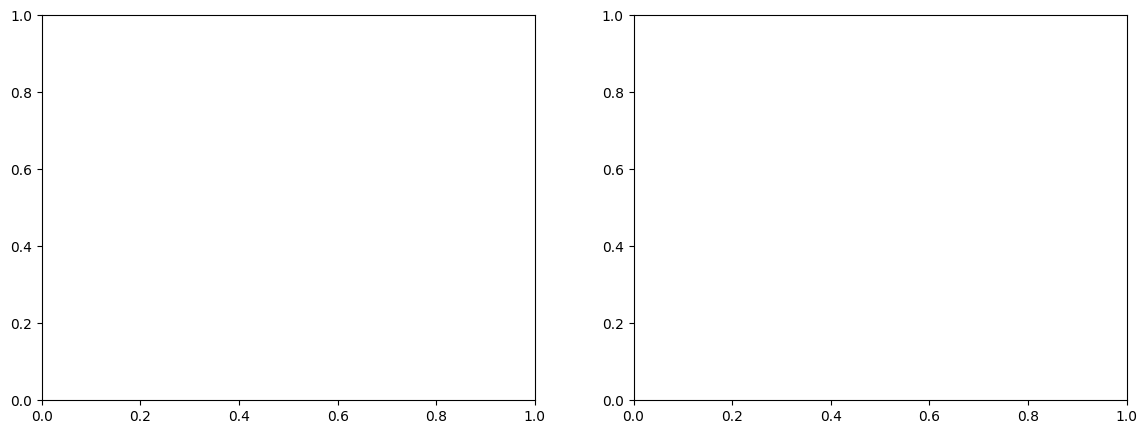

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Убедимся, что нужные столбцы числовые
for col in ['views', 'comments']:
    if col in df.columns:
        # Очистка и преобразование
        s = df[col].astype(str).str.replace(',', '.', regex=False)
        s = pd.to_numeric(s, errors='coerce')
        df[col] = s
    else:
        raise KeyError(f"Столбец '{col}' отсутствует в df")

# Группировка только по строкам, где есть данные
hourly = df.groupby('hour')[['views', 'comments']].mean().reset_index()

# Проверка, что столбцы есть
if 'views' not in hourly.columns or 'comments' not in hourly.columns:
    raise ValueError("Столбцы 'views' или 'comments' отсутствуют в hourly")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=hourly, x='hour', y='views', marker='o', ax=axes[0])
axes[0].set_title('Среднее число просмотров по часам')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Просмотры')

sns.lineplot(data=hourly, x='hour', y='comments', marker='o', ax=axes[1])
axes[1].set_title('Среднее число комментариев по часам')
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Комментарии')

plt.tight_layout()
plt.show()

# Вывод максимумов
max_views_hour = hourly.loc[hourly['views'].idxmax(), 'hour']
max_comments_hour = hourly.loc[hourly['comments'].idxmax(), 'hour']

print(f"Макс. просмотры — в {max_views_hour}:00")
print(f"Макс. комментарии — в {max_comments_hour}:00")

# Проверка для geektimes.ru
geek_df = df[df['domain'] == 'geektimes.ru']
if not geek_df.empty and 'comments' in geek_df.columns:
    valid_geek = geek_df.dropna(subset=['comments'])
    if not valid_geek.empty:
        row = valid_geek.loc[valid_geek['comments'].idxmax()]
        print(f"\nМакс. комментарии на Geektimes: {row['comments']} в {row['hour']}:00")

8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20
авторов чаще всего минусуют?

Авторы с наибольшим числом минусов (сумма):
           sum  mean
author              
@Jeditobe  0.0   NaN
@Mithgol   0.0   NaN
@Mordatyj  0.0   NaN
@SLY_G     0.0   NaN
@Shapelez  0.0   NaN


ValueError: List of boxplot statistics and `positions` values must have same the length

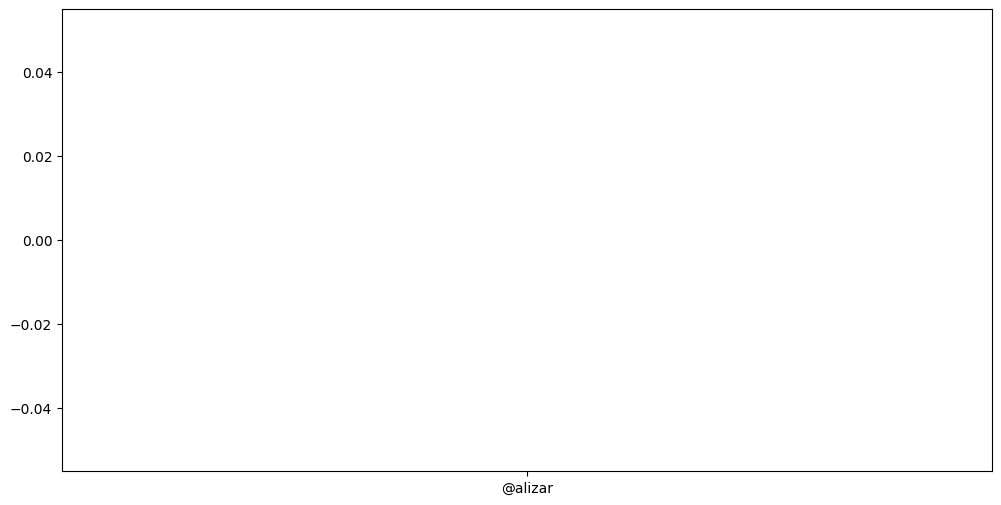

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Топ-20 авторов по количеству публикаций
top20_authors = df['author'].value_counts().head(20).index
df_top20 = df[df['author'].isin(top20_authors)].copy()

# Принудительно приводим votes_minus к числу (на всякий случай)
df_top20['votes_minus'] = pd.to_numeric(df_top20['votes_minus'], errors='coerce')

# Агрегация: сумма и среднее по минусам
minus_stats = (
    df_top20.groupby('author')['votes_minus']
    .agg(['sum', 'mean'])
    .sort_values('sum', ascending=False)
)

print("Авторы с наибольшим числом минусов (сумма):")
print(minus_stats.head())

# Визуализация
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top20, x='author', y='votes_minus')
plt.xticks(rotation=90)
plt.title('Распределение минусов у топ-20 авторов')
plt.tight_layout()
plt.show()

9. Используя Seaborn, сравните субботы и понедельники. Правда ли, что по субботам
авторы пишут в основном днём, а по понедельникам — в основном вечером?

In [ ]:
# Фильтруем дни: Понедельник = 1, Суббота = 6
monday = df[df["dayofweek"] == 1]
saturday = df[df["dayofweek"] == 6]

plt.figure(figsize=(10, 6))
sns.histplot(monday["hour"], bins=24, alpha=0.6, label="Понедельник", color="blue", kde=False)
sns.histplot(saturday["hour"], bins=24, alpha=0.6, label="Суббота", color="orange", kde=False)
plt.xlabel("Час публикации")
plt.ylabel("Количество публикаций")
plt.title("Время публикаций: понедельник vs суббота")
plt.legend()
plt.show()

# Анализ:
monday_peak = monday["hour"].mode().iloc[0] if not monday.empty else None
saturday_peak = saturday["hour"].mode().iloc[0] if not saturday.empty else None

print(f"Пик публикаций в понедельник: {monday_peak}:00")
print(f"Пик публикаций в субботу: {saturday_peak}:00")